In [24]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
BASE_DIR = Path().resolve().parent

In [25]:
# upload df
df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "test1_Asheboro BoE Black AC_BT.csv")
df = df.dropna()

In [26]:
num_candidates = 5
candidates = df["Candidate"][0:num_candidates]

In [27]:
def most_frequent(List):
    return max(set(List), key=List.count)

In [28]:
all_winners = []
for i in range(0,len(df),5):
    curr_sim = df[i:(i+5)]
    winners = curr_sim[curr_sim["Plurality Result"] == True]
    all_winners.append(winners['Candidate'].to_list())

In [29]:
all_winners = tuple(all_winners)

In [30]:
counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 9 iterations out of 30


 Ballots Observations

In [31]:
# Code modified from https://stackoverflow.com/questions/41045510/pandas-read-csv-ignore-rows-after-a-blank-line

total_blank_index = 0
list_of_dfs = []
for i in range(32):
    ballots = pd.read_csv(BASE_DIR / "Results/Ballots/test1_Asheboro BoE Black AC_ballots_BT.csv", skip_blank_lines=False, skiprows = total_blank_index)
    blank_df = ballots.loc[ballots.isnull().all(1)]
    if len(blank_df) > 0:
        first_blank_index = blank_df.index[0]
        total_blank_index += first_blank_index
        total_blank_index += 2
        ballots = ballots[:first_blank_index]
        ballots['iteration_number'] = i
        list_of_dfs.append(ballots)
    if len(blank_df) == 0:
        ballots['iteration_number'] = i
        list_of_dfs.append(ballots)
        break
        
list_of_dfs

[   Ranking_1 Ranking_2 Ranking_3 Ranking_4 Ranking_5 Weight  iteration_number
 0     {'Ry'}    {'To'}    {'Gw'}    {'Gi'}    {'Me'}      3                 0
 1     {'Ry'}    {'To'}    {'Me'}    {'Gi'}    {'Gw'}      3                 0
 2     {'Ry'}    {'To'}    {'Me'}    {'Gw'}    {'Gi'}      1                 0
 3     {'Ry'}    {'To'}    {'Gi'}    {'Me'}    {'Gw'}     10                 0
 4     {'Ry'}    {'To'}    {'Gi'}    {'Gw'}    {'Me'}      2                 0
 5     {'Ry'}    {'Gw'}    {'Me'}    {'Gi'}    {'To'}      4                 0
 6     {'Ry'}    {'Gw'}    {'Gi'}    {'To'}    {'Me'}      1                 0
 7     {'Ry'}    {'Gw'}    {'Gi'}    {'Me'}    {'To'}      8                 0
 8     {'Ry'}    {'Me'}    {'Gw'}    {'Gi'}    {'To'}     19                 0
 9     {'Ry'}    {'Me'}    {'Gw'}    {'To'}    {'Gi'}      1                 0
 10    {'Ry'}    {'Me'}    {'Gi'}    {'To'}    {'Gw'}    137                 0
 11    {'Ry'}    {'Me'}    {'Gi'}    {'Gw'}    {'To'

In [32]:
full_df = pd.concat(list_of_dfs)

In [33]:
full_df = full_df.astype({"Weight" : "int"})

In [34]:
# Find the specific simulations where the correct candidates won in Plurality

In [35]:
all_winners

(['Gidget Kidd', 'Ryan Patton', 'Todd Dulaney'],
 ['Gidget Kidd', 'Gwen Williams', 'Ryan Patton'],
 ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Melissa Calloway', 'Todd Dulaney'],
 ['Gwen Williams', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Gwen Williams', 'Melissa Calloway'],
 ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Gwen Williams', 'Ryan Patton'],
 ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Gwen Williams', 'Melissa Calloway'],
 ['Gwen Williams', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Ryan Patton', 'Todd Dulaney'],
 ['Gidget Kidd', 'Melissa Calloway', 'Todd Dulaney'],
 ['Gwen Williams', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton'],
 ['Gidget Kidd', 'Gwen Williams', 'Melissa Calloway'],
 ['Gidget Kidd', 'Gwen Williams', 'Melissa Cal

In [36]:
# Code copied from https://www.geeksforgeeks.org/python/python-find-index-containing-string-in-list/
simulations_to_search = [i for i, value in enumerate(all_winners) if value == ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']]

In [37]:
simulations_to_search


[2, 6, 8, 9, 12, 16, 19, 22, 28]

In [38]:
# Let's visualize first chioce votes in each of these simulations to the actual plurality results

In [39]:
results = pd.read_csv(BASE_DIR / "Election_Data_Sheets" / "csv" / "results_pct_20231107.csv")
results = results[results["Contest Name"] == "ASHEBORO CITY SCHOOLS BOARD OF EDUCATION"]
results = results[["Choice", "Total Votes"]]
results = results.groupby("Choice")['Total Votes'].sum().reset_index()
results = results[results["Choice"] != "Write-In (Miscellaneous)"] #Drop Write-Ins, since that's not a choice in the Simulation

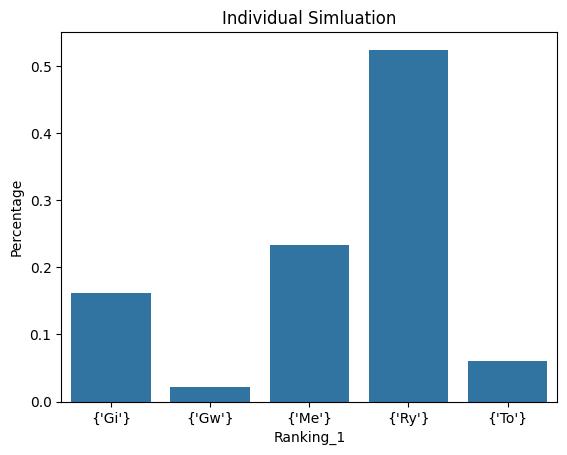

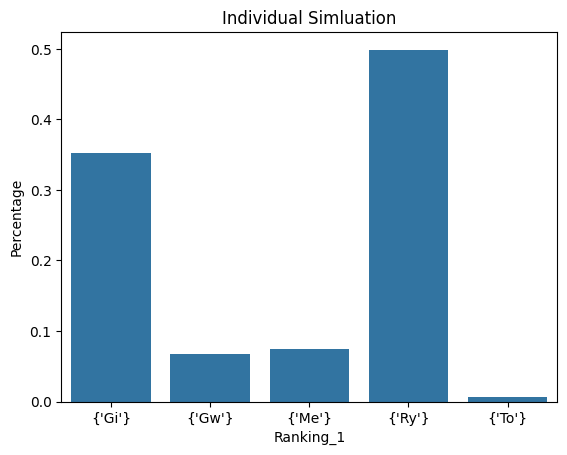

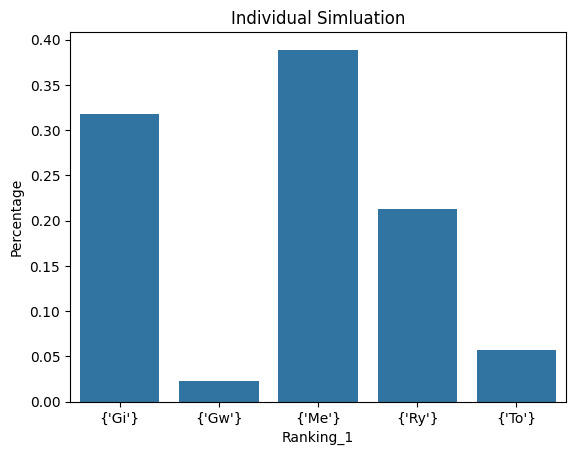

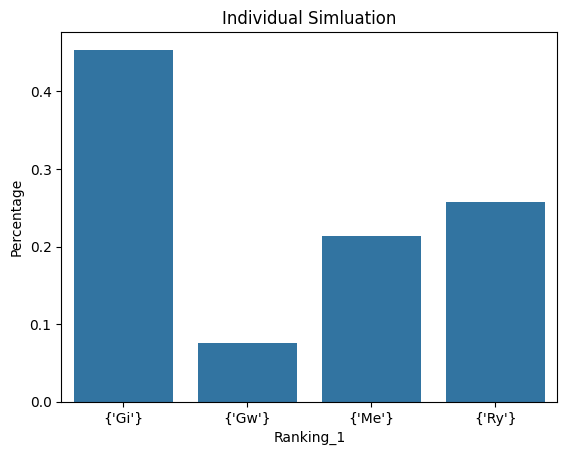

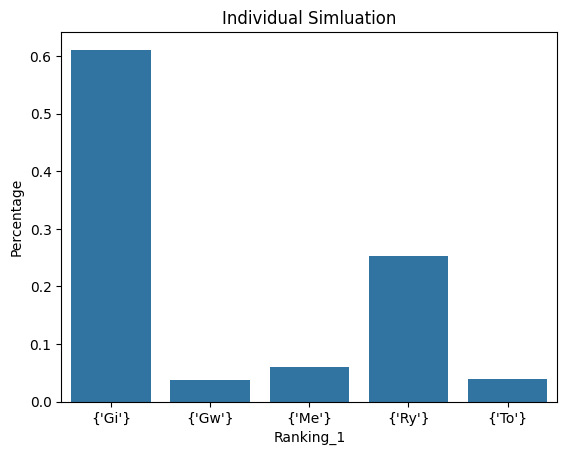

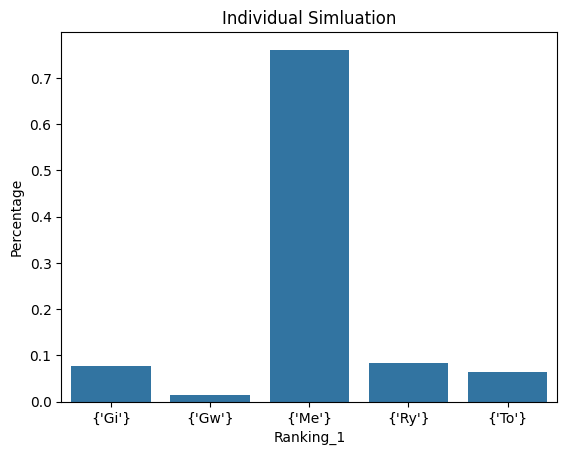

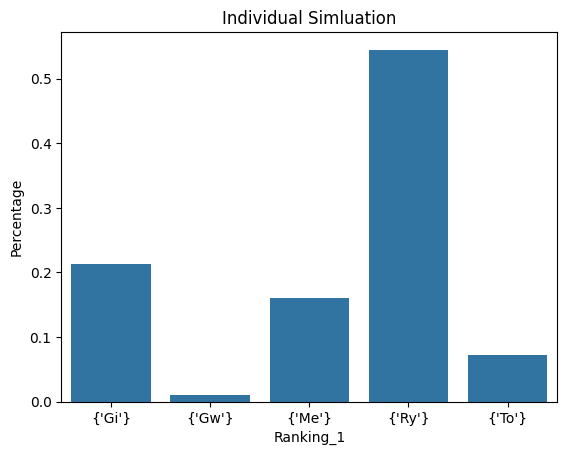

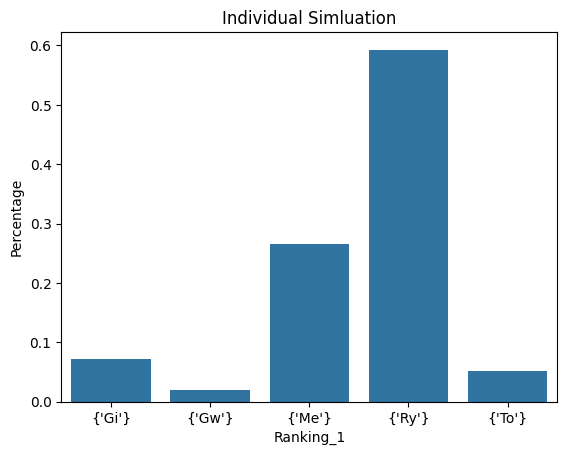

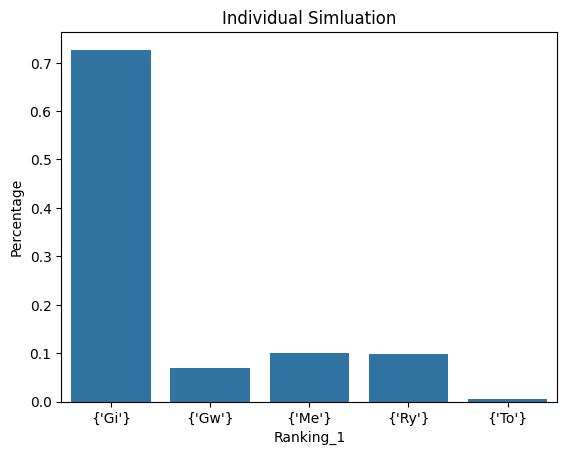

In [52]:
for i in simulations_to_search:
    simulation_df = full_df[full_df["iteration_number"]==i]
    simulation_df = simulation_df.groupby("Ranking_1")['Weight'].sum().reset_index()
    simulation_df["Percentage"] = simulation_df["Weight"]/1000 #Weight the columns so that it's percentage of votes, not number of votes
    sns.barplot(simulation_df, x="Ranking_1", y="Percentage")
    plt.title("Individual Simluation")
    plt.show()

    

In [43]:
# What happens if you average all of the 'good' simulations?
# Combine into one large dataframe
simulation_df = full_df[full_df["iteration_number"]==simulations_to_search[0]]
for i in simulations_to_search[1:]:
    temp_df = full_df[full_df["iteration_number"]==i]
    simulation_df = pd.concat([simulation_df, temp_df])


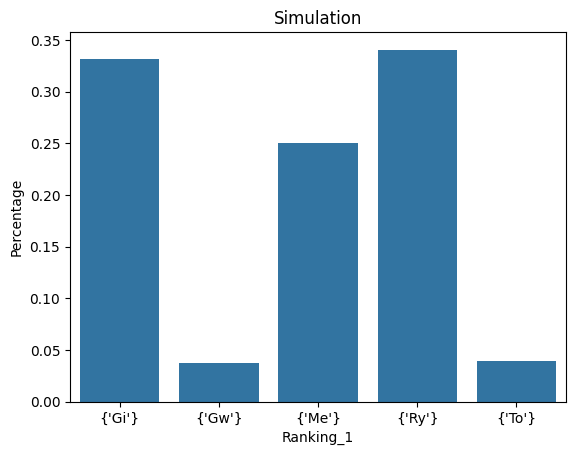

In [ ]:
simulation_df = simulation_df.groupby("Ranking_1")['Weight'].sum().reset_index()
simulation_df["Percentage"] = simulation_df["Weight"]/(len(simulations_to_search)*1000) #Weight the columns so that it's percentage of votes, not number of votes
sns.barplot(simulation_df, x="Ranking_1", y="Percentage")
plt.title("Correct Plurality Winner Simulations Combined")
plt.show()


Text(0.5, 1.0, 'Actual Results')

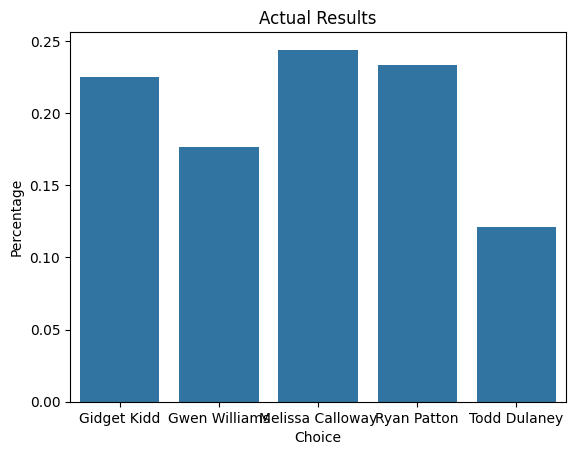

In [53]:
total_votes = results["Total Votes"].sum()
results["Percentage"] = results["Total Votes"] / total_votes
sns.barplot(results, x="Choice", y="Percentage")
plt.title("Actual Results")

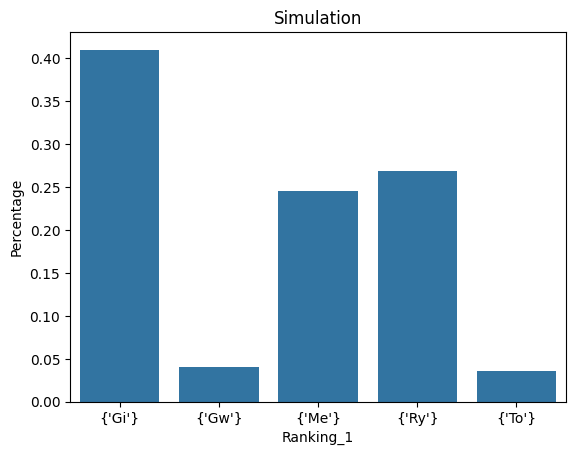

In [46]:
# What about all the simulations, no matter whether good or bad?
simulation_df = full_df.groupby("Ranking_1")['Weight'].sum().reset_index()
simulation_df["Percentage"] = simulation_df["Weight"]/30000 #Weight the columns so that it's percentage of votes, not number of votes
sns.barplot(simulation_df, x="Ranking_1", y="Percentage")
plt.title("Simulation")
plt.show()